In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn Imports ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer # Import this
from sklearn.pipeline import Pipeline # Import this

results_output_path = Path('../results/seasonality/')
results_output_path.joinpath('figures').mkdir(parents=True, exist_ok=True)

In [2]:
data_file = Path('../data/T100_domestic/processed/final_enriched_t100_data.parquet')
df = pd.read_parquet(data_file)

In [3]:
df.columns

Index(['PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'UNIQUE_CARRIER',
       'AIRLINE_ID', 'UNIQUE_CARRIER_NAME', 'UNIQUE_CARRIER_ENTITY', 'REGION',
       'CARRIER', 'CARRIER_NAME', 'CARRIER_GROUP', 'CARRIER_GROUP_NEW',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID',
       'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_FIPS',
       'ORIGIN_STATE_NM', 'ORIGIN_COUNTRY', 'ORIGIN_COUNTRY_NAME',
       'ORIGIN_WAC', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID',
       'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR',
       'DEST_STATE_FIPS', 'DEST_STATE_NM', 'DEST_COUNTRY', 'DEST_COUNTRY_NAME',
       'DEST_WAC', 'YEAR', 'QUARTER', 'MONTH', 'DISTANCE_GROUP', 'CLASS',
       'DATA_SOURCE', 'File_name', 'date', 'origin_airport_name',
       'origin_airport_type', 'origin_country_name', 'origin_continent',
       'origin_iso_country', 'dest_airport_name', 'dest_airport_type',
       'dest_country_name', 'dest_continent', 'dest_iso

In [4]:
df.Travel_type.unique()

array(['Domestic', 'Inbound International', 'Outbound International'],
      dtype=object)

In [5]:
# Filter for international flights (to/from US)
df_intl = df[(df['Travel_type'].isin(['Inbound International', 'Outbound International'])) & (df.YEAR == 2019)].copy()

# Create a single 'foreign_airport' column (using the airport code)
df_intl['foreign_airport'] = np.where(
    df_intl['Travel_type'] == 'Inbound International', 
    df_intl['ORIGIN'], 
    df_intl['DEST']
)

# --- 3. Engineer Seasonality Features ---
print("--- Engineering seasonality features ---")
# Group by foreign airport and month, summing passengers across all years
monthly_totals = df_intl.groupby(['foreign_airport', 'MONTH'])['PASSENGERS'].sum().reset_index()

# Pivot to create a "seasonality signature" for each airport
df_seasonality = monthly_totals.pivot_table(
    index='foreign_airport', 
    columns='MONTH', 
    values='PASSENGERS'
).fillna(0)



# Filter out very small airports
min_passengers = 100000 
df_seasonality = df_seasonality[df_seasonality.sum(axis=1) > min_passengers]

# Normalize the data (convert to percentages) to compare shapes
df_seasonality_norm = df_seasonality.apply(lambda x: (x / x.sum()) * 100, axis=1)


--- Engineering seasonality features ---


In [6]:
df_seasonality_norm

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
foreign_airport,,,,,,,,,,,,
ACC,7.452056,6.288955,8.035659,7.834511,8.03908,8.539214,9.459432,9.658527,8.615157,7.77362,7.674414,10.629374
ADD,6.688211,6.504632,7.577528,7.286483,8.509073,9.082817,10.341567,11.342143,8.092861,7.043229,6.928177,10.603279
AGU,7.57367,5.606785,6.17454,6.865462,8.026362,8.965778,11.013694,9.750696,8.454744,8.351565,9.018178,10.198525
AKL,10.988974,8.813226,9.529465,7.506738,6.877838,6.676128,8.449955,7.050757,7.548382,7.375728,8.334265,10.848544
AMM,6.066339,4.703963,7.061571,8.205208,7.604552,11.021396,12.129865,12.009242,9.175119,8.064187,6.432781,7.525778
...,...,...,...,...,...,...,...,...,...,...,...,...
YYJ,8.240568,6.63934,9.713645,8.979116,10.582131,9.781963,10.642412,10.562931,6.235237,6.321862,6.107085,6.19371
YYZ,7.460805,7.533563,9.259847,8.797558,8.420213,8.590123,8.933934,9.152215,7.842163,8.241852,7.720705,8.047021
ZCL,7.971509,6.030193,7.8174,7.147293,8.690685,9.024205,10.196508,8.664617,7.8197,7.976109,6.900412,11.761368


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.ticker import FuncFormatter


scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_seasonality_norm)

# Apply K-Means (let's try 5 clusters)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_seasonality_norm['cluster'] = kmeans.fit_predict(scaled_features)

# --- 5. Visualize Cluster Results ---
print("--- Visualizing Clusters ---")

# Add cluster labels back to the (non-normalized) data for plotting
df_seasonality['cluster'] = df_seasonality_norm['cluster']

# Prepare data for plotting
df_plot = df_seasonality.reset_index().melt(
    id_vars=['foreign_airport', 'cluster'], 
    var_name='MONTH', 
    value_name='PASSENGERS'
)

--- Visualizing Clusters ---


In [8]:
df_plot

,foreign_airport,cluster,MONTH,PASSENGERS
0,ACC,3,1,10892.0
1,ADD,3,1,26450.0
2,AGU,3,1,14020.0
3,AKL,0,1,124812.0
4,AMM,2,1,17250.0
...,...,...,...,...
1963,YYJ,2,12,13871.0
1964,YYZ,3,12,1098811.0
1965,ZCL,3,12,15340.0
1966,ZIH,0,12,15122.0


--- Visualizing Clusters (Normalized) ---


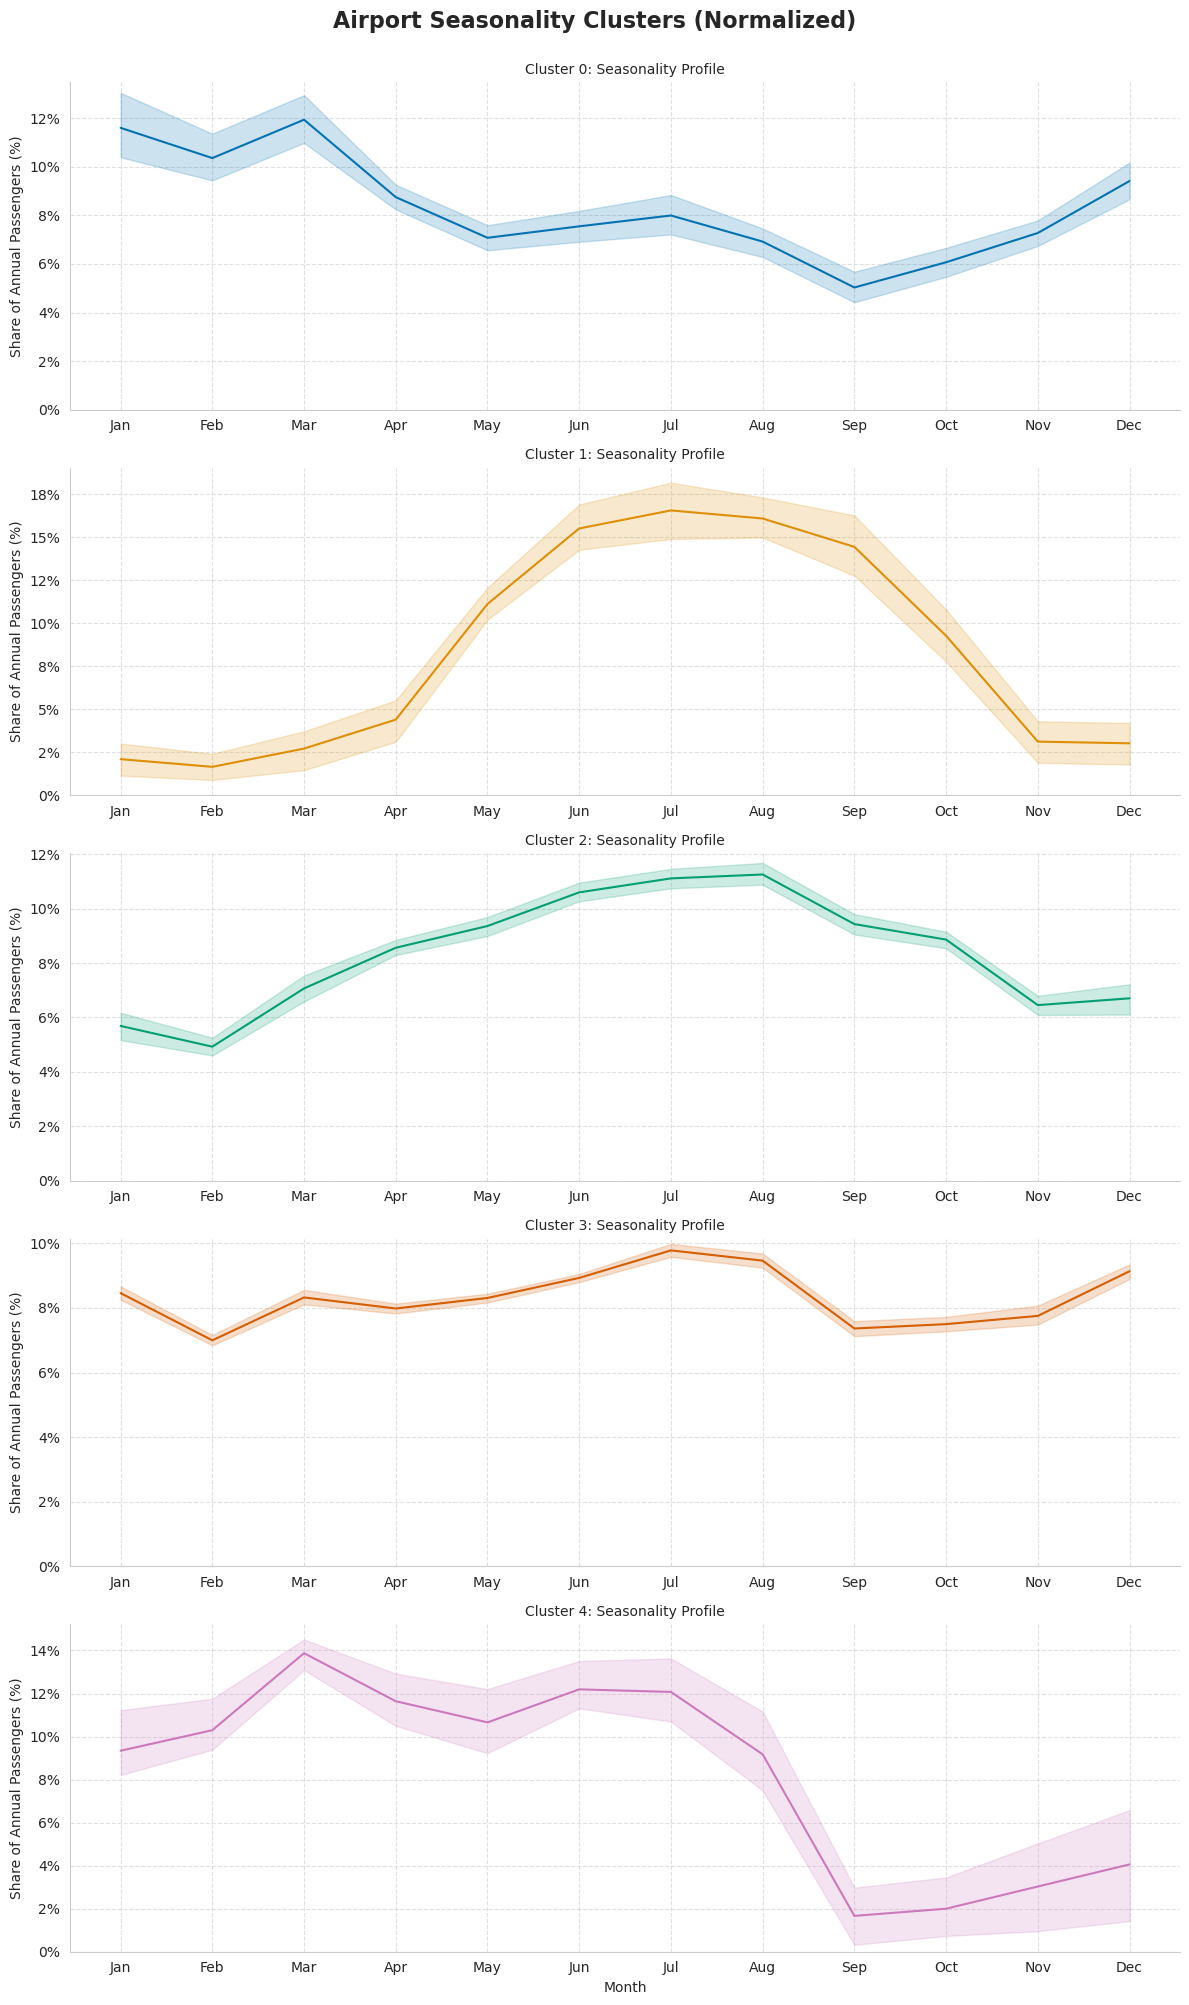

In [19]:
# --- 5. Visualize Cluster Results (Using Percentages) ---
print("--- Visualizing Clusters (Normalized) ---")

# --- THIS IS THE KEY CHANGE ---
# Create the plot data from the NORMALIZED DataFrame
df_plot = df_seasonality_norm.reset_index().melt(
    id_vars=['foreign_airport', 'cluster'], 
    var_name='MONTH', 
    value_name='PASSENGERS_PCT' # New name for clarity
)

g = sns.relplot(
    data=df_plot,
    x='MONTH',
    y='PASSENGERS_PCT', # Plot the percentage column
    hue='cluster',
    row='cluster',
    kind='line',
    palette='colorblind',
    height=4,
    aspect=3,
    facet_kws={'sharey': False, 'sharex': False},
    legend=False
)

g.set_axis_labels("Month", "Share of Annual Passengers (%)")
g.set_titles("Cluster {row_name}: Seasonality Profile")
g.fig.suptitle('Airport Seasonality Clusters (Normalized)', fontsize=16, fontweight='bold', y=1)

# Format the Y-axis as a percentage
formatter = FuncFormatter(lambda y, pos: f'{y:.0f}%')
month_labels = [pd.to_datetime(str(m), format='%m').strftime('%b') for m in range(1, 13)]

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(formatter)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(0, ax.get_ylim()[1])
    
plt.tight_layout()
plt.savefig(results_output_path / "figures" / "airport_seasonality_clusters_normalized.png", dpi=300)


--- Performing PCA ---


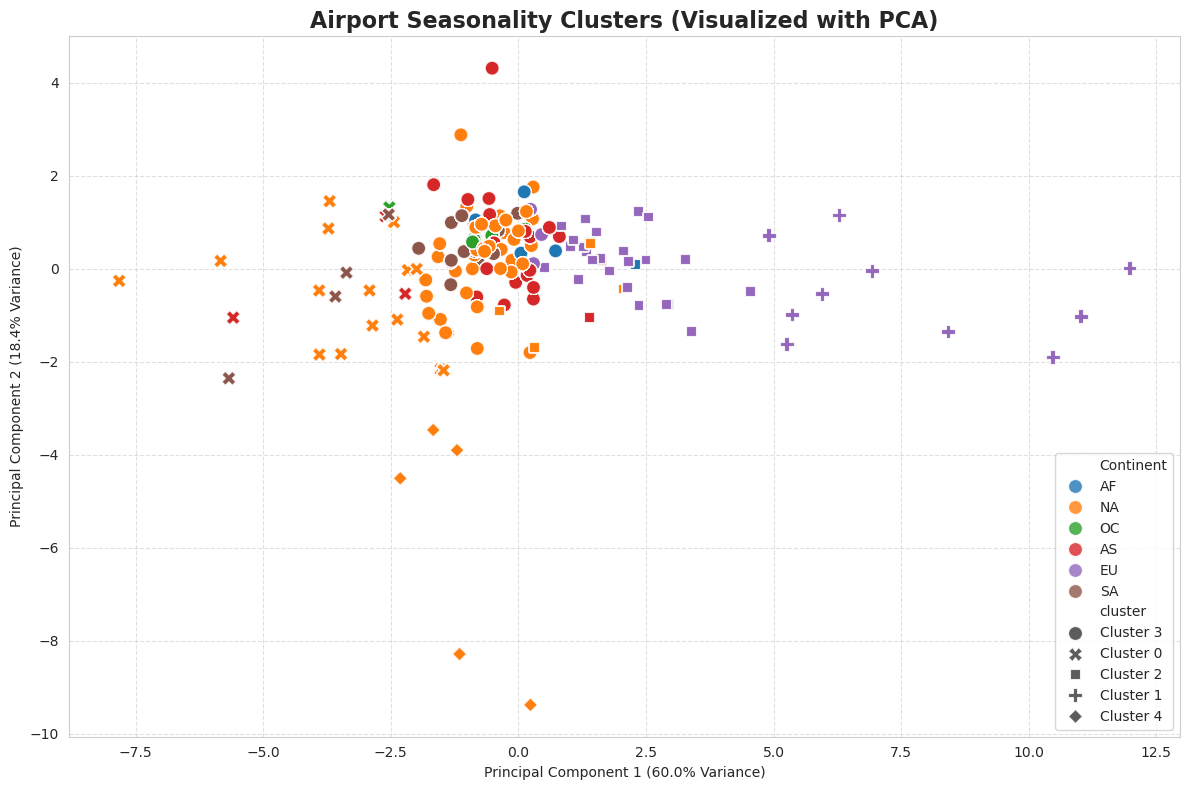

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# (Assuming 'df_seasonality_norm' and 'scaled_features' exist from the previous cell)
# ...

# --- 1. Perform PCA ---
print("\n--- Performing PCA ---")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# --- 2. Create the Plot DataFrame ---
# Create a DataFrame from the PCA results
df_pca = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2'],
    index=df_seasonality_norm.index # Use the airport code as the index
)
# Add the cluster labels from your clustering results
df_pca['cluster'] = 'Cluster ' + df_seasonality_norm['cluster'].astype(str)

df_pca = df_pca.merge(df[['ORIGIN', 'origin_continent']].rename(columns={'origin_continent': 'Continent'}), left_on='foreign_airport', right_on='ORIGIN', how='left')

# --- 3. Create the PCA Scatter Plot ---
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Continent',  # Color by continent
    style='cluster', # Shape by cluster
    s=100,
    alpha=0.8
)


# --- 4. Format Plot ---
ax.set_title('Airport Seasonality Clusters (Visualized with PCA)', fontsize=16, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(results_output_path / "figures" / "airport_seasonality_pca.png", dpi=300)

In [15]:
df_pca[df_pca.ORIGIN == 'CUN']

,PC1,PC2,cluster,ORIGIN,origin_continent
131554,-1.528191,-1.088005,Cluster 3,CUN,NA
131555,-1.528191,-1.088005,Cluster 3,CUN,NA
131556,-1.528191,-1.088005,Cluster 3,CUN,NA
131557,-1.528191,-1.088005,Cluster 3,CUN,NA
131558,-1.528191,-1.088005,Cluster 3,CUN,NA
...,...,...,...,...,...
171727,-1.528191,-1.088005,Cluster 3,CUN,NA
171728,-1.528191,-1.088005,Cluster 3,CUN,NA
171729,-1.528191,-1.088005,Cluster 3,CUN,NA
171730,-1.528191,-1.088005,Cluster 3,CUN,NA


In [16]:
df_pca[df_pca.ORIGIN == 'YYZ']

,PC1,PC2,cluster,ORIGIN,origin_continent
955150,-0.664049,0.375639,Cluster 3,YYZ,NA
955151,-0.664049,0.375639,Cluster 3,YYZ,NA
955152,-0.664049,0.375639,Cluster 3,YYZ,NA
955153,-0.664049,0.375639,Cluster 3,YYZ,NA
955154,-0.664049,0.375639,Cluster 3,YYZ,NA
...,...,...,...,...,...
1019515,-0.664049,0.375639,Cluster 3,YYZ,NA
1019516,-0.664049,0.375639,Cluster 3,YYZ,NA
1019517,-0.664049,0.375639,Cluster 3,YYZ,NA
1019518,-0.664049,0.375639,Cluster 3,YYZ,NA


In [21]:
df_pca[df_pca['cluster'] == 'Cluster 4'].ORIGIN.unique()

array(['ELH', 'FPO', 'MHH', 'PUJ', 'RTB'], dtype=object)

In [4]:
# --- 2. Feature Engineering & Preprocessing ---
print("--- Preparing data for modeling ---")

categorical_features = ['ORIGIN', 'DEST', 'UNIQUE_CARRIER', 'origin_continent', 'dest_continent']
numerical_features = ['YEAR', 'MONTH', 'DISTANCE', 'origin_gdp', 'origin_population', 'dest_gdp', 'dest_population', 'U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon)']
target_col = 'PASSENGERS'

# Create the modeling DataFrame, dropping rows where any of these features are missing
df_model = df[categorical_features + numerical_features + [target_col]].dropna()

# --- 3. Split Data (Train/Test) ---
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Create Preprocessing Pipelines ---
# This is the memory-efficient way to handle mixed data types

# Pipeline for numerical features: just scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline for categorical features: encode as integers
categorical_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# --- 5. Combine Pipelines with ColumnTransformer ---
# This applies the correct transformation to the correct columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any columns not listed
)

# --- 6. Create the Full Modeling Pipeline ---
# This chainlinks the preprocessor and the model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2))
])


--- Preparing data for modeling ---


In [ ]:

# --- 7. Train the Model ---
print("--- Training Random Forest pipeline... ---")
# Fit the entire pipeline on the raw (unscaled, unencoded) training data
rf_pipeline.fit(X_train, y_train)



--- Training Random Forest pipeline... ---


In [ ]:
# --- 8. Evaluate the Model ---
print("\n--- Evaluating model performance ---")
predictions = rf_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Test Set R-squared: {r2:.2%}")
print(f"Test Set RMSE: {rmse:,.2f} passengers")